<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <img src="../assets/branding/logoUgrupo.png" alt="Universidad del Magdalena y GIDSYC" style="height: 76px; max-width: 34%; object-fit: contain;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Modelos de difusión para IA generativa</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 05</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Muestreo iterativo y evaluación cualitativa</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Semillero GIDSYC | Facultad de Ingenierías | Programa de Ingeniería de Sistemas</div>
    </div>
    <img src="../assets/branding/logo_semillero.png" alt="Semillero GIDSYC" style="height: 74px; object-fit: contain;">
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
  <div><strong>Grupo:</strong> GIDSYC</div>
  <div><strong>Unidad:</strong> Semillero GIDSYC</div>
  <div><strong>Universidad:</strong> Universidad del Magdalena</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>

## Pregunta directriz

> ¿Cómo se transforma una semilla gaussiana en una muestra visual coherente cuando aplicamos iterativamente el paso inverso de un DDPM?

El notebook 04 cerró el primer ciclo entrenable: ya contamos con un modelo que aproxima la función $\epsilon_\theta(x_t,t)$. Sin embargo, una red entrenada no es todavía un generador en sentido operativo. La generación aparece cuando esa predicción de ruido se inserta repetidamente en una cadena inversa que va desde una variable gaussiana inicial hasta una imagen final.

Este notebook se concentra en esa cadena. El objetivo no es introducir una arquitectura nueva ni modificar la pérdida. El objetivo es estudiar qué hace el procedimiento de muestreo, cómo evoluciona una trayectoria intermedia, qué cambia al variar la semilla inicial y qué se pierde cuando reducimos el número de evaluaciones del modelo.

## Objetivos

Al finalizar este notebook, el estudiante debería estar en capacidad de:

1. Formalizar el paso inverso de un DDPM a partir de la predicción de ruido $\epsilon_\theta(x_t,t)$.
2. Distinguir entre la media aproximada $\mu_\theta(x_t,t)$, la varianza posterior $\tilde{\beta}_t$ y la perturbación gaussiana adicional de cada iteración.
3. Analizar trayectorias intermedias del muestreo para reconocer cómo emerge la estructura visual.
4. Comparar cualitativamente varias semillas bajo un mismo modelo entrenado.
5. Estudiar el efecto de reducir el presupuesto de evaluaciones del modelo durante el muestreo.
6. Relacionar las expresiones matemáticas del paso inverso con implementaciones tensoriales concretas.

## Marco conceptual

En un DDPM no condicional, la red no produce directamente una imagen limpia. Lo que produce es una estimación del ruido presente en una muestra intermedia $x_t$. La generación surge al combinar esa predicción con la agenda de ruido del proceso directo. En cada tiempo debemos construir una media para la transición inversa y, salvo en el último paso, volver a introducir una pequeña perturbación gaussiana.

Esto tiene una consecuencia importante para la interpretación. La calidad final no depende solo de que el modelo prediga bien el ruido en un tiempo aislado. Depende también de que esa predicción sea suficientemente consistente a lo largo de toda la trayectoria. Errores pequeños pueden acumularse porque el resultado de un paso se convierte inmediatamente en la entrada del siguiente.

Desde el punto de vista experimental, este notebook separa dos preguntas distintas. Primero: ¿qué aspecto tiene una trayectoria de muestreo razonable cuando el modelo ya fue entrenado? Segundo: ¿cómo cambia esa trayectoria si mantenemos el modelo fijo y modificamos el procedimiento de muestreo? Esa separación es útil porque evita mezclar problemas de arquitectura, entrenamiento y sampling dentro del mismo análisis.

## Formulación matemática

Recordemos la forma cerrada del proceso directo:

$$
x_t
=
\sqrt{\bar{\alpha}_t}\,x_0
+
\sqrt{1-\bar{\alpha}_t}\,\epsilon,
\qquad
\epsilon\sim\mathcal{N}(0,I).
$$

El modelo entrenado aproxima la función

$$
\epsilon_\theta(x_t,t).
$$

A partir de esa predicción, el paso inverso DDPM utiliza la media

$$
\mu_\theta(x_t,t)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
 x_t
 -
 \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}
 \epsilon_\theta(x_t,t)
\right).
$$

La varianza posterior asociada es

$$
\tilde{\beta}_t
=
\beta_t
\frac{1-\bar{\alpha}_{t-1}}{1-\bar{\alpha}_t}.
$$

Para $t>1$, el muestreo se escribe como

$$
x_{t-1}
=
\mu_\theta(x_t,t)
+
\sqrt{\tilde{\beta}_t}\,z,
\qquad
z\sim\mathcal{N}(0,I).
$$

Además, la predicción de ruido puede reescribirse como una estimación de la muestra limpia:

$$
\hat{x}_0
=
\frac{x_t-\sqrt{1-\bar{\alpha}_t}\,\epsilon_\theta(x_t,t)}{\sqrt{\bar{\alpha}_t}}.
$$

Esta ecuación será útil más adelante para comparar un muestreo completo con una versión determinista de menor costo inspirada en saltos de tiempo. No será exactamente la cadena inversa DDPM original, pero sí una aproximación controlada que nos permite estudiar el compromiso entre costo y calidad.

<div style="margin: 18px 0 10px 0; text-align: center;">
  <img src="../assets/figures/formulacion_muestreo_inverso.png" alt="Descomposición visual de un paso inverso DDPM" style="max-width: 100%; border: 1px solid #d0d7de; border-radius: 6px;" />
</div>

<div style="text-align: center; color: #4a5568; font-size: 0.95em; margin-bottom: 6px;">
  Descomposición visual del paso inverso: la red predice ruido, esa predicción define una media inversa y una perturbación gaussiana controlada produce la muestra siguiente.
</div>

## Preparación del entorno

Fijamos dependencias, rutas, semillas y agenda temporal para que el análisis del muestreo sea reproducible y quede acoplado al mismo experimento base del notebook 04.

In [1]:
import math
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from difusion.data.quickdraw import load_quickdraw_npz

DATASET_PATH = ROOT / "data" / "quickdraw" / "processed" / "quickdraw_house_50k_28x28.npz"
CHECKPOINT_DIR = ROOT / "models"
CHECKPOINT_PATH = CHECKPOINT_DIR / "quickdraw_house_ddpm_tiny_unet.pt"

SEED = 20260421
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["image.cmap"] = "gray_r"

print("PyTorch:", torch.__version__)
print("Dispositivo:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(DEVICE))
else:
    print("Advertencia: no se detectó GPU. El entrenamiento o el muestreo pueden tardar bastante más.")
print("Checkpoint:", CHECKPOINT_PATH.relative_to(ROOT))

PyTorch: 2.8.0+cu126
Dispositivo: cuda:0
GPU: NVIDIA RTX A6000
Checkpoint: models/quickdraw_house_ddpm_tiny_unet.pt


## Criterio experimental

El análisis reutiliza exactamente la misma familia de modelo del notebook 04: una U-Net mínima condicionada por tiempo. Esa decisión evita cambiar simultáneamente arquitectura y muestreo. Si cambiáramos ambos elementos a la vez, la lectura de resultados sería ambigua.

El cuaderno seguirá tres comparaciones principales. Primero, una trayectoria completa de la cadena inversa DDPM con estados intermedios guardados en tiempos seleccionados. Segundo, una comparación entre semillas distintas bajo el mismo modelo entrenado. Tercero, una comparación entre dos esquemas de muestreo: la cadena inversa probabilística completa y una aproximación determinista por saltos de tiempo. En esa tercera parte no cambiaremos solo el número de evaluaciones; también cambiaremos la actualización temporal. Por eso la lectura debe ser precisa: no estaremos aislando una sola causa, sino estudiando un compromiso conjunto entre costo computacional y fidelidad del procedimiento.

In [2]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró {DATASET_PATH}. "
        "Verifica que esta distribucion incluya data/quickdraw/processed/quickdraw_house_50k_28x28.npz"
    )

split = load_quickdraw_npz(DATASET_PATH, split="train")
MAX_TRAIN_SAMPLES = 20_000
BATCH_SIZE = 256

x_train = split.normalized_images[:MAX_TRAIN_SAMPLES]
x_train_tensor = torch.from_numpy(x_train[:, None, :, :])
loader = DataLoader(
    TensorDataset(x_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=0,
)

T = 1000
beta_inicio = 1e-4
beta_fin = 2e-2

betas = torch.linspace(beta_inicio, beta_fin, T, dtype=torch.float32, device=DEVICE)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)
timesteps = torch.arange(1, T + 1, device=DEVICE)

print(f"Clase: {split.class_names[0]}")
print(f"Muestras usadas: {len(x_train_tensor)}")
print(f"Mini-lotes por época: {len(loader)}")
print(f"Agenda lineal: beta_1={betas[0].item():.6f}, beta_T={betas[-1].item():.6f}")

Clase: house
Muestras usadas: 20000
Mini-lotes por época: 78
Agenda lineal: beta_1=0.000100, beta_T=0.020000


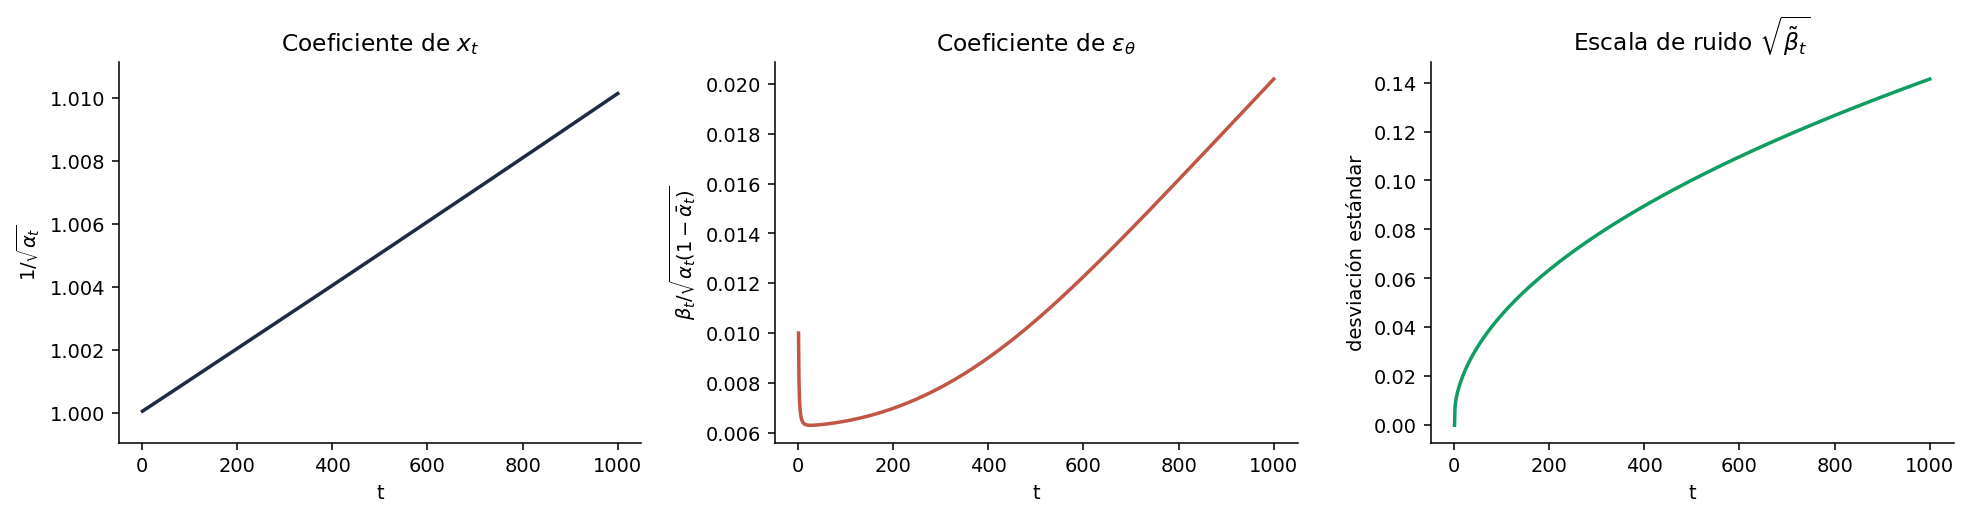

In [3]:
def posterior_variance_from_index(t_index):
    if t_index == 0:
        return torch.tensor(0.0, device=DEVICE)
    return betas[t_index] * (1.0 - alpha_bars[t_index - 1]) / (1.0 - alpha_bars[t_index])


coeff_xt = 1.0 / torch.sqrt(alphas)
coeff_eps = betas / torch.sqrt(alphas * (1.0 - alpha_bars))
posterior_std = torch.sqrt(torch.stack([posterior_variance_from_index(int(i)) for i in range(T)]))

fig, axes = plt.subplots(1, 3, figsize=(14.2, 3.8))
axes[0].plot(timesteps.cpu(), coeff_xt.cpu(), color="#1f2a44", linewidth=1.8)
axes[0].set_title(r"Coeficiente de $x_t$")
axes[0].set_xlabel("t")
axes[0].set_ylabel(r"$1/\sqrt{\alpha_t}$")
axes[0].set_ylim(float(coeff_xt.min().cpu()) * 0.999, float(coeff_xt.max().cpu()) * 1.001)

axes[1].plot(timesteps.cpu(), coeff_eps.cpu(), color="#c05746", linewidth=1.8)
axes[1].set_title(r"Coeficiente de $\epsilon_\theta$")
axes[1].set_xlabel("t")
axes[1].set_ylabel(r"$\beta_t/\sqrt{\alpha_t(1-\bar{\alpha}_t)}$")

axes[2].plot(timesteps.cpu(), posterior_std.cpu(), color="#119c62", linewidth=1.8)
axes[2].set_title(r"Escala de ruido $\sqrt{\tilde{\beta}_t}$")
axes[2].set_xlabel("t")
axes[2].set_ylabel("desviación estándar")
fig.tight_layout()

## Recuperación del modelo entrenado

Para estudiar muestreo necesitamos un modelo funcional. El notebook intentará cargar un checkpoint local del modelo entrenado en el notebook 04. Si no existe, entrenará nuevamente la misma arquitectura con la misma configuración básica y guardará el resultado. Con esto el cuaderno queda reutilizable y no obliga a repetir entrenamiento en cada ejecución.

In [4]:
def q_sample(x0, t_index, eps=None):
    if eps is None:
        eps = torch.randn_like(x0)
    alpha_bar_t = alpha_bars[t_index].view(-1, 1, 1, 1)
    xt = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1.0 - alpha_bar_t) * eps
    return xt, eps


def to_image_range(x):
    return torch.clamp((x + 1.0) / 2.0, 0.0, 1.0)


def reconstruct_x0_from_epsilon(xt, eps_pred, t_index):
    alpha_bar_t = alpha_bars[t_index].view(-1, 1, 1, 1)
    return (xt - torch.sqrt(1.0 - alpha_bar_t) * eps_pred) / torch.sqrt(alpha_bar_t)


def sinusoidal_time_embedding(t, dim=64):
    half = dim // 2
    t = t.float()
    freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device) / max(half - 1, 1))
    args = t[:, None] * freqs[None, :]
    return torch.cat([torch.sin(args), torch.cos(args)], dim=1)


class TimeConditionedBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.time_proj = nn.Linear(time_dim, out_channels)
        self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()
        self.act = nn.SiLU()

    def forward(self, x, t_emb):
        time_bias = self.time_proj(t_emb)[:, :, None, None]
        h = self.act(self.conv1(x) + time_bias)
        h = self.conv2(h)
        return self.act(h + self.skip(x))


class TinyTimeUNet(nn.Module):
    def __init__(self, time_dim=64, base=48):
        super().__init__()
        self.time_dim = time_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        self.input_block = TimeConditionedBlock(1, base, time_dim)
        self.down1 = nn.Conv2d(base, 2 * base, kernel_size=4, stride=2, padding=1)
        self.encoder_block = TimeConditionedBlock(2 * base, 2 * base, time_dim)
        self.down2 = nn.Conv2d(2 * base, 2 * base, kernel_size=4, stride=2, padding=1)
        self.middle_block = TimeConditionedBlock(2 * base, 2 * base, time_dim)
        self.up1 = nn.ConvTranspose2d(2 * base, 2 * base, kernel_size=4, stride=2, padding=1)
        self.decoder_block = TimeConditionedBlock(4 * base, base, time_dim)
        self.up2 = nn.ConvTranspose2d(base, base, kernel_size=4, stride=2, padding=1)
        self.output_block = TimeConditionedBlock(2 * base, base, time_dim)
        self.output_conv = nn.Conv2d(base, 1, kernel_size=3, padding=1)

    def forward(self, x, t_index):
        t_emb = sinusoidal_time_embedding(t_index, dim=self.time_dim)
        t_emb = self.time_mlp(t_emb)
        skip_28 = self.input_block(x, t_emb)
        h_14 = self.encoder_block(self.down1(skip_28), t_emb)
        h_7 = self.middle_block(self.down2(h_14), t_emb)
        h = self.up1(h_7)
        h = self.decoder_block(torch.cat([h, h_14], dim=1), t_emb)
        h = self.up2(h)
        h = self.output_block(torch.cat([h, skip_28], dim=1), t_emb)
        return self.output_conv(h)


model = TinyTimeUNet(time_dim=64, base=48).to(DEVICE)
num_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros entrenables: {num_params:,}")

Parámetros entrenables: 969,953


Checkpoint cargado correctamente.
Configuración guardada: {'epochs': 50, 'learning_rate': 0.0001, 'batch_size': 256, 'max_train_samples': 20000, 'T': 1000, 'seed': 20260421, 'elapsed_seconds': 102.07}


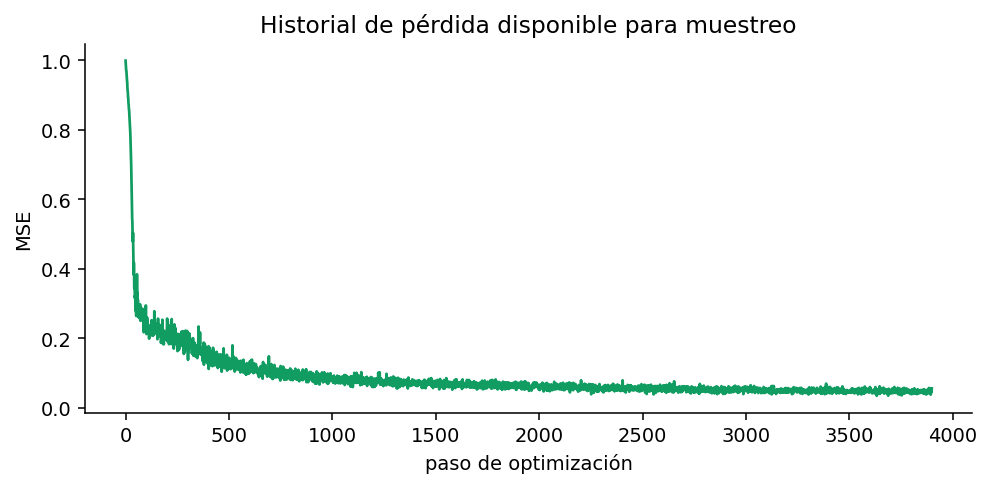

In [5]:
LEARNING_RATE = 1e-4
EPOCHS = 50
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

training_metadata = None
if CHECKPOINT_PATH.exists():
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    loss_history = checkpoint.get("loss_history", [])
    epoch_history = checkpoint.get("epoch_history", [])
    training_metadata = checkpoint.get("config", {})
    print("Checkpoint cargado correctamente.")
    if training_metadata:
        print("Configuración guardada:", training_metadata)
else:
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    loss_history = []
    epoch_history = []
    start_time = time.perf_counter()

    model.train()
    for epoch in range(1, EPOCHS + 1):
        epoch_losses = []
        for (x0,) in loader:
            x0 = x0.to(DEVICE)
            b = x0.shape[0]
            t_index = torch.randint(0, T, (b,), device=DEVICE)
            eps = torch.randn_like(x0)
            xt, eps = q_sample(x0, t_index, eps)
            eps_pred = model(xt, t_index)
            loss = torch.mean((eps - eps_pred) ** 2)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            value = float(loss.detach().cpu())
            loss_history.append(value)
            epoch_losses.append(value)

        epoch_mean = float(np.mean(epoch_losses))
        epoch_history.append(epoch_mean)
        print(f"época {epoch:02d}/{EPOCHS} | loss promedio={epoch_mean:.4f} | loss final={epoch_losses[-1]:.4f}")

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start_time
    training_metadata = {
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "max_train_samples": MAX_TRAIN_SAMPLES,
        "T": T,
        "seed": SEED,
        "elapsed_seconds": round(elapsed, 2),
    }
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "loss_history": loss_history,
            "epoch_history": epoch_history,
            "config": training_metadata,
        },
        CHECKPOINT_PATH,
    )
    print(f"Checkpoint guardado en {CHECKPOINT_PATH.relative_to(ROOT)}")
    print(f"Tiempo total de entrenamiento: {elapsed:.2f} s")

fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot(loss_history, color="#119c62", linewidth=1.4)
ax.set_title("Historial de pérdida disponible para muestreo")
ax.set_xlabel("paso de optimización")
ax.set_ylabel("MSE")
fig.tight_layout()

<div style="margin: 18px 0 10px 0; text-align: center;">
  <img src="../assets/figures/diagrama_paso_inverso_ddpm.png" alt="Diagrama del paso inverso probabilístico DDPM" style="max-width: 100%; border: 1px solid #d0d7de; border-radius: 6px;" />
</div>

El diagrama resume la operación que se repetirá durante el muestreo. En cada tiempo, la red estima el ruido presente en $x_t$; esa predicción define la media $\mu_\theta(x_t,t)$ y la cadena añade una perturbación gaussiana con escala $\sqrt{\tilde{\beta}_t}$. La muestra no aparece en un único salto: se obtiene al iterar este paso desde ruido puro hasta $x_0$.

## Reconstrucción puntual del paso inverso

Antes de recorrer una trayectoria completa conviene observar un solo paso con detalle. Elegiremos una imagen real, la corromperemos hasta un tiempo intermedio y usaremos el modelo entrenado para estimar tanto el ruido como la muestra limpia y la media inversa correspondiente. Esta visualización no muestra todavía generación libre; muestra la mecánica interna de una transición.

En el código indexaremos los tiempos como `0, ..., T-1`. Cuando aparezca una etiqueta visual del tipo `t_index = 699`, debe leerse exactamente con esa misma convención discreta, que es la que seguiremos en el resto del notebook.

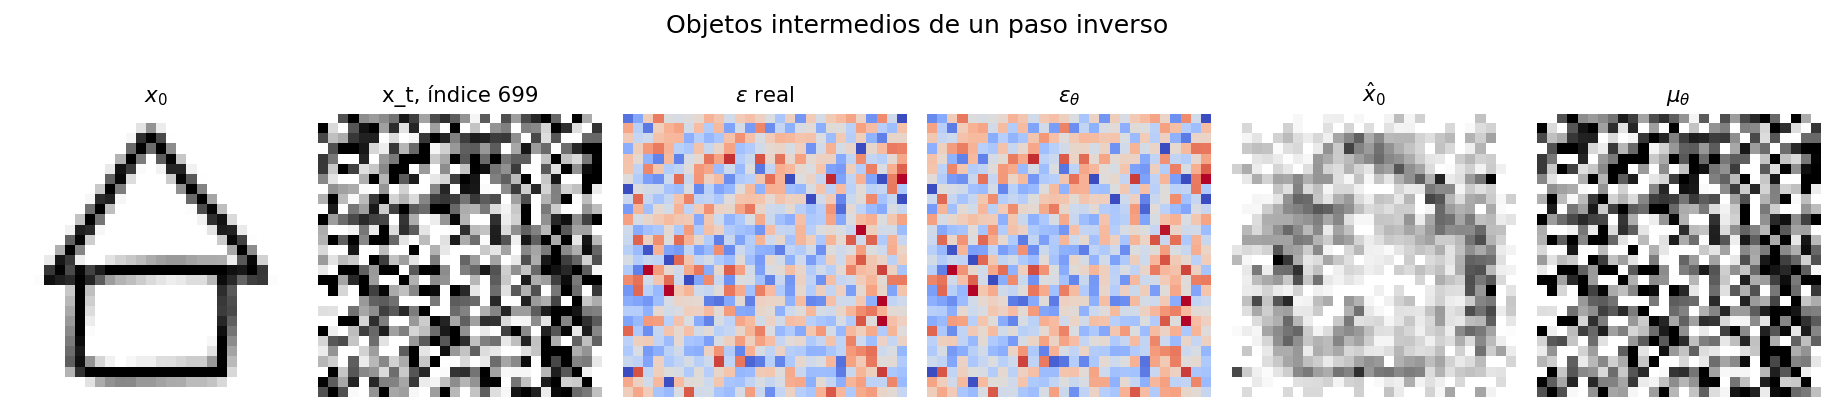

In [6]:
model.eval()
with torch.no_grad():
    sample_x0 = x_train_tensor[12:13].to(DEVICE)
    chosen_t = torch.tensor([699], device=DEVICE)
    eps_true = torch.randn_like(sample_x0)
    x_t, _ = q_sample(sample_x0, chosen_t, eps_true)
    eps_pred = model(x_t, chosen_t)
    x0_hat = reconstruct_x0_from_epsilon(x_t, eps_pred, chosen_t)
    beta_t = betas[chosen_t.item()]
    alpha_t = alphas[chosen_t.item()]
    alpha_bar_t = alpha_bars[chosen_t.item()]
    mu_theta = (1.0 / torch.sqrt(alpha_t)) * (
        x_t - (beta_t / torch.sqrt(1.0 - alpha_bar_t)) * eps_pred
    )

panels = [
    (sample_x0[0, 0], r"$x_0$"),
    (x_t[0, 0], f"x_t, índice {chosen_t.item()}"),
    (eps_true[0, 0], r"$\epsilon$ real"),
    (eps_pred[0, 0], r"$\epsilon_\theta$"),
    (x0_hat[0, 0], r"$\hat{x}_0$"),
    (mu_theta[0, 0], r"$\mu_\theta$"),
]

fig, axes = plt.subplots(1, 6, figsize=(13.2, 3.0))
for ax, (image, title) in zip(axes, panels):
    if "epsilon" in title or r"$\epsilon$" in title:
        ax.imshow(image.detach().cpu().numpy(), cmap="coolwarm", vmin=-2.5, vmax=2.5)
    else:
        ax.imshow(to_image_range(image).detach().cpu().numpy(), vmin=0, vmax=1)
    ax.set_title(title, fontsize=11)
    ax.axis("off")
fig.suptitle("Objetos intermedios de un paso inverso", y=1.02, fontsize=13)
fig.tight_layout()

## Trayectoria de muestreo inverso DDPM

Ahora sí partiremos de ruido gaussiano puro. Guardaremos estados intermedios de varias muestras a tiempos seleccionados para observar cómo aparece la estructura global. La lectura correcta de esta figura no consiste en buscar perfección temprana. Lo importante es reconocer que las imágenes dejan de ser ruido indiferenciado y empiezan a organizarse alrededor de patrones de casa.

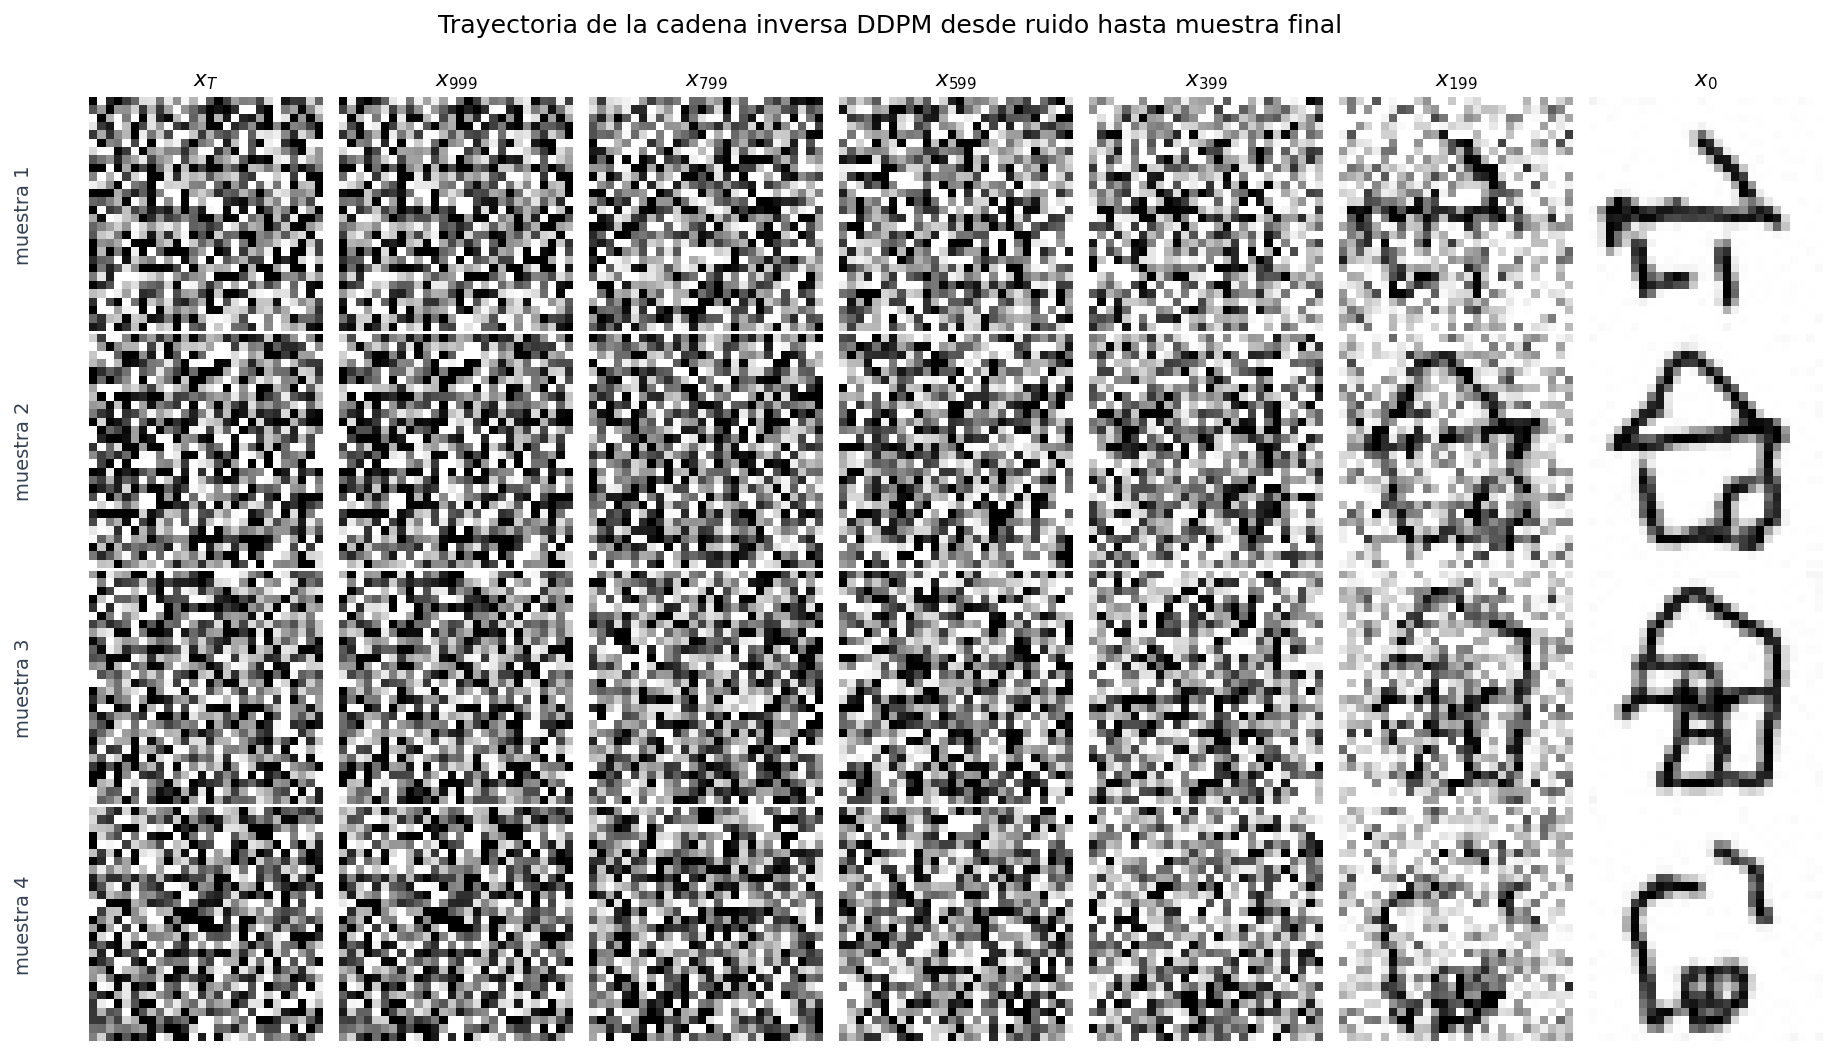

In [7]:
def make_generator(seed):
    if DEVICE.type == "cuda":
        return torch.Generator(device="cuda").manual_seed(seed)
    return torch.Generator().manual_seed(seed)


@torch.no_grad()
def p_sample_step(model, x_t, t_index, generator=None):
    b = x_t.shape[0]
    t_batch = torch.full((b,), t_index, device=x_t.device, dtype=torch.long)
    beta_t = betas[t_index]
    alpha_t = alphas[t_index]
    alpha_bar_t = alpha_bars[t_index]

    eps_pred = model(x_t, t_batch)
    mean = (1.0 / torch.sqrt(alpha_t)) * (
        x_t - (beta_t / torch.sqrt(1.0 - alpha_bar_t)) * eps_pred
    )

    if t_index == 0:
        return mean

    posterior_var = betas[t_index] * (1.0 - alpha_bars[t_index - 1]) / (1.0 - alpha_bar_t)
    noise = torch.randn(x_t.shape, device=x_t.device, generator=generator)
    return mean + torch.sqrt(torch.clamp(posterior_var, min=1e-20)) * noise


@torch.no_grad()
def sample_reverse_ddpm(model, n_samples=4, seed=0, save_steps=(999, 799, 599, 399, 199, 0)):
    model.eval()
    generator = make_generator(seed)
    x = torch.randn((n_samples, 1, 28, 28), device=DEVICE, generator=generator)
    snapshots = {T: x.detach().cpu().clone()}
    save_steps = set(save_steps)
    for t_index in reversed(range(T)):
        x = p_sample_step(model, x, t_index, generator=generator)
        if t_index in save_steps:
            snapshots[t_index] = x.detach().cpu().clone()
    return snapshots


trajectory_steps = (999, 799, 599, 399, 199, 0)
snapshots = sample_reverse_ddpm(model, n_samples=4, seed=SEED + 11, save_steps=trajectory_steps)
ordered_keys = [T] + list(trajectory_steps)
title_map = {T: r"$x_T$", 999: r"$x_{999}$", 799: r"$x_{799}$", 599: r"$x_{599}$", 399: r"$x_{399}$", 199: r"$x_{199}$", 0: r"$x_0$"}

fig, axes = plt.subplots(4, len(ordered_keys), figsize=(13.5, 7.4))
for col, key in enumerate(ordered_keys):
    images = snapshots[key]
    for row in range(4):
        axes[row, col].imshow(to_image_range(images[row, 0]).numpy(), vmin=0, vmax=1, interpolation="nearest")
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(title_map[key], fontsize=11)
        if col == 0:
            axes[row, col].text(
                -0.28, 0.50, f"muestra {row + 1}",
                transform=axes[row, col].transAxes,
                rotation=90, va="center", ha="center", fontsize=10, color="#344054",
            )
fig.suptitle("Trayectoria de la cadena inversa DDPM desde ruido hasta muestra final", y=0.995, fontsize=13)
fig.tight_layout(rect=[0.04, 0, 1, 0.97], pad=0.15)

## Variabilidad por semilla

El modelo permanece fijo, pero la cadena parte de una semilla gaussiana distinta. Eso basta para producir muestras diferentes. La diversidad que observemos aquí no debe interpretarse como control semántico; todavía no hay condición. Lo que sí podemos evaluar es si el modelo transforma distintas semillas en dibujos plausibles de la misma categoría.

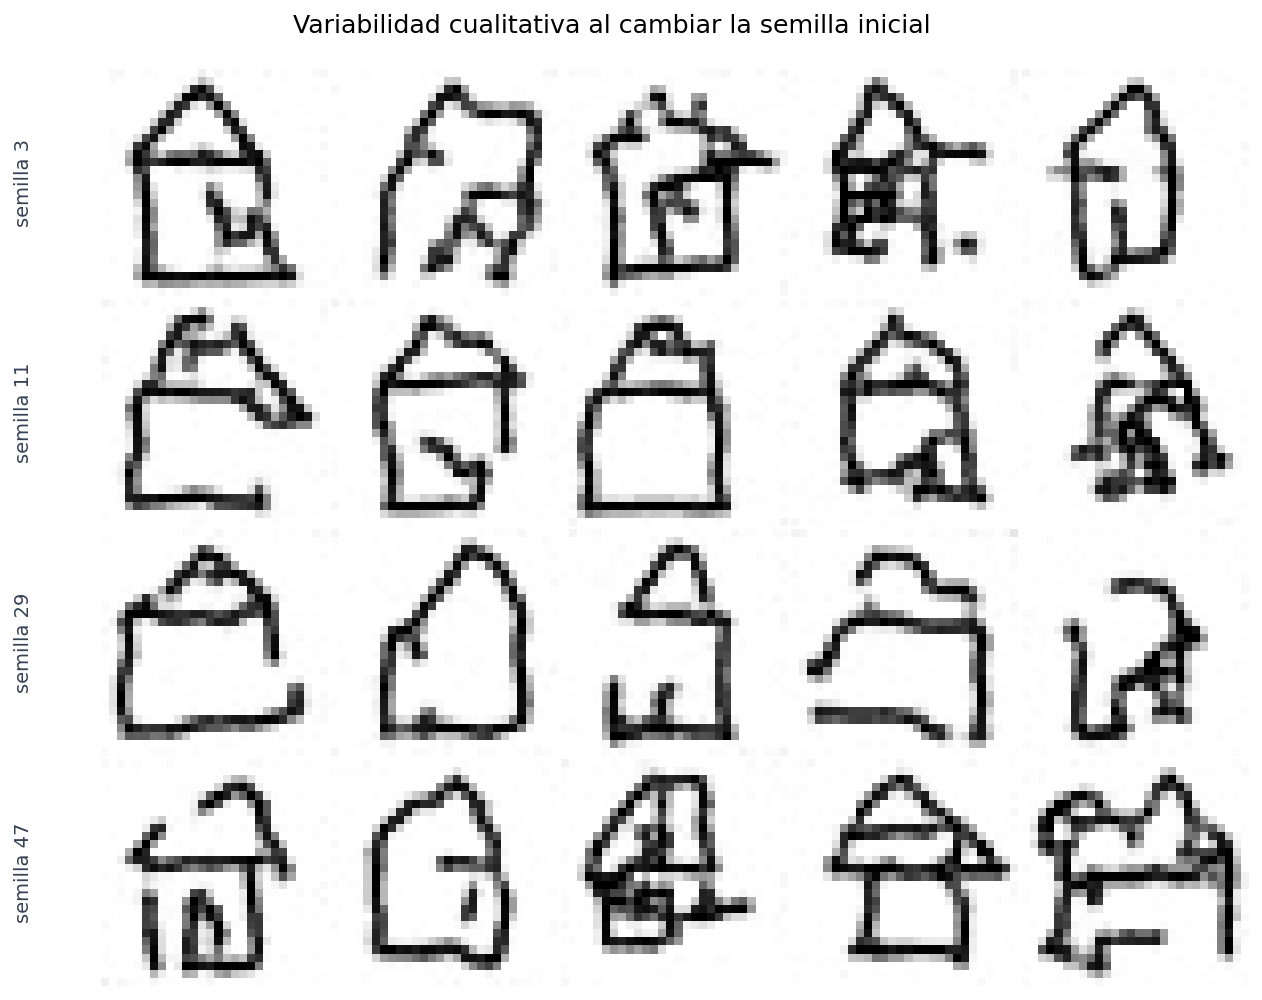

In [8]:
seed_values = [3, 11, 29, 47]
seed_results = []
for seed in seed_values:
    generated = sample_reverse_ddpm(model, n_samples=5, seed=seed, save_steps=(0,))[0]
    seed_results.append((seed, generated))

fig, axes = plt.subplots(len(seed_values), 5, figsize=(9.2, 7.0))
for row, (seed, images) in enumerate(seed_results):
    for col in range(5):
        axes[row, col].imshow(to_image_range(images[col, 0]).numpy(), vmin=0, vmax=1, interpolation="nearest")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].text(
                -0.34, 0.50, f"semilla {seed}",
                transform=axes[row, col].transAxes,
                rotation=90, va="center", ha="center", fontsize=10, color="#344054",
            )
fig.suptitle("Variabilidad cualitativa al cambiar la semilla inicial", y=0.995, fontsize=13)
fig.tight_layout(rect=[0.05, 0, 1, 0.97], pad=0.15)

## Comparación entre cadena inversa DDPM y aproximación determinista

En la cadena inversa DDPM realizamos una evaluación del modelo por cada tiempo de la agenda. Eso es costoso. Para explorar un régimen de menor costo construiremos una versión determinista por saltos de tiempo. En cada índice temporal estimamos $\hat{x}_0$ y lo proyectamos directamente a un tiempo anterior seleccionado:

$$
x_s
=
\sqrt{\bar{\alpha}_s}\,\hat{x}_0
+
\sqrt{1-\bar{\alpha}_s}\,\epsilon_\theta(x_t,t),
\qquad s<t.
$$

Esta actualización no es la cadena inversa DDPM exacta. Se parece más a una discretización determinista por saltos, útil aquí para visualizar un compromiso conjunto entre costo y fidelidad del esquema de muestreo. Por lo tanto, la comparación final no debe interpretarse como un experimento puro de “menos pasos” en sentido estricto, sino como un contraste entre la cadena inversa probabilística completa y una aproximación más barata.

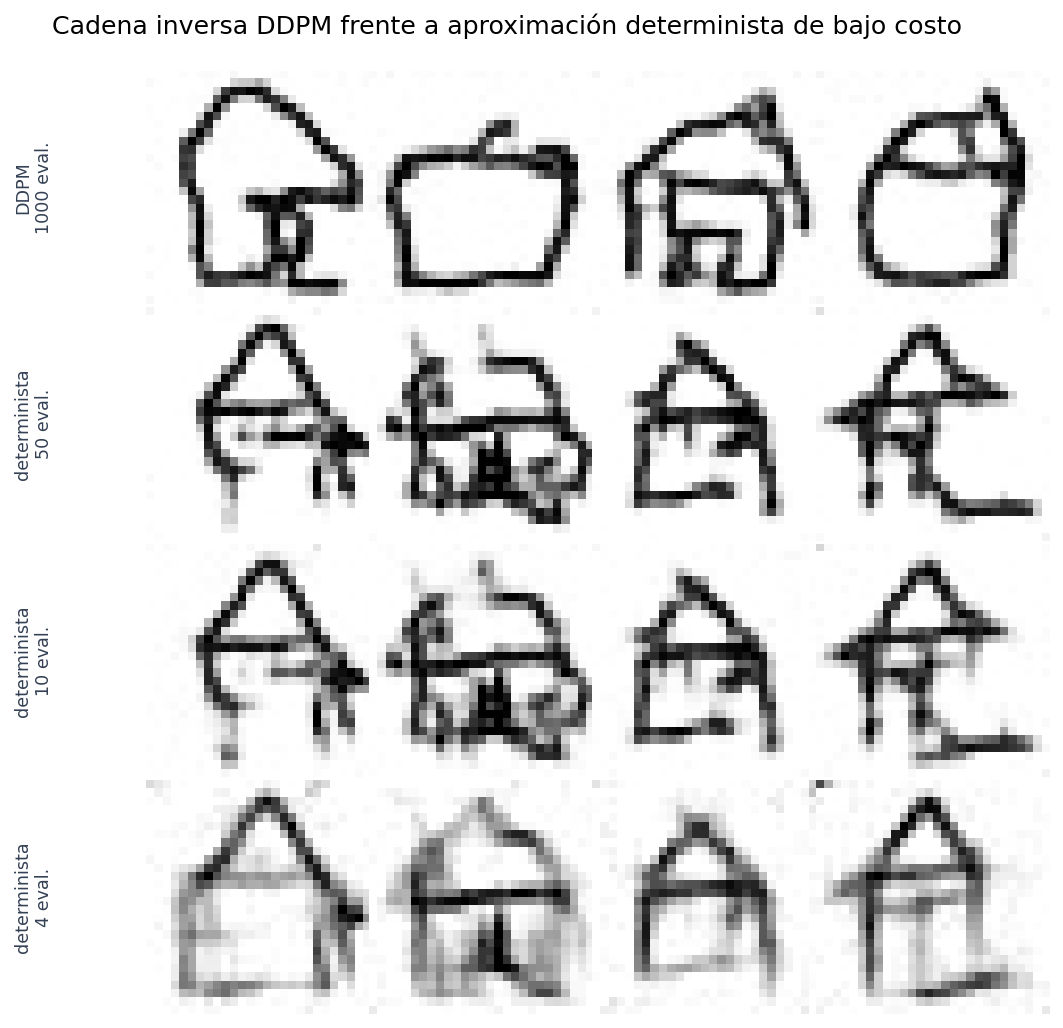

In [9]:
@torch.no_grad()
def sample_subsampled_deterministic(model, n_samples=4, seed=0, num_evals=1000):
    model.eval()
    indices = np.linspace(T - 1, 0, num_evals, dtype=int).tolist()
    indices = list(dict.fromkeys(indices))
    if indices[-1] != 0:
        indices.append(0)

    generator = make_generator(seed)
    x = torch.randn((n_samples, 1, 28, 28), device=DEVICE, generator=generator)

    for idx, t_index in enumerate(indices):
        t_batch = torch.full((n_samples,), t_index, device=DEVICE, dtype=torch.long)
        eps_pred = model(x, t_batch)
        x0_hat = reconstruct_x0_from_epsilon(x, eps_pred, t_batch)

        if t_index == 0 or idx == len(indices) - 1:
            x = x0_hat
            break

        next_t = indices[idx + 1]
        if next_t == 0:
            x = x0_hat
        else:
            alpha_bar_next = alpha_bars[next_t]
            x = torch.sqrt(alpha_bar_next) * x0_hat + torch.sqrt(1.0 - alpha_bar_next) * eps_pred

    return x.detach().cpu().clone(), len(indices)


budget_results = []
ddpm_images = sample_reverse_ddpm(model, n_samples=4, seed=SEED + 101, save_steps=(0,))[0]
budget_results.append(("DDPM", 1000, ddpm_images))
for budget in [50, 10, 4]:
    images, effective_steps = sample_subsampled_deterministic(model, n_samples=4, seed=SEED + 101, num_evals=budget)
    budget_results.append(("determinista", effective_steps, images))

fig, axes = plt.subplots(len(budget_results), 4, figsize=(7.8, 7.2))
for row, (mode, effective_steps, images) in enumerate(budget_results):
    for col in range(4):
        axes[row, col].imshow(to_image_range(images[col, 0]).numpy(), vmin=0, vmax=1, interpolation="nearest")
        axes[row, col].axis("off")
        if col == 0:
            label = f"{mode}\n{effective_steps} eval."
            axes[row, col].text(
                -0.48, 0.50, label,
                transform=axes[row, col].transAxes,
                rotation=90, va="center", ha="center", fontsize=9, color="#344054",
            )
fig.suptitle("Cadena inversa DDPM frente a aproximación determinista de bajo costo", y=0.995, fontsize=13)
fig.tight_layout(rect=[0.08, 0, 1, 0.97], pad=0.15)

## Síntesis

El muestreo DDPM no consiste en aplicar la red una sola vez, sino en insertar repetidamente la predicción $\epsilon_\theta(x_t,t)$ dentro de una cadena inversa probabilística. La media $\mu_\theta(x_t,t)$ organiza el desplazamiento hacia regiones más compatibles con la distribución de datos, mientras que la varianza posterior mantiene el carácter estocástico del proceso.

Las trayectorias intermedias muestran que la estructura no aparece de golpe. Aparece gradualmente, a medida que se acumulan muchos pasos pequeños. La comparación final sugiere que abaratar el muestreo exige cuidado: cuando pasamos de la cadena inversa probabilística completa a una aproximación determinista con saltos amplios, la muestra final conserva parte de la categoría, pero pierde nitidez estructural y estabilidad geométrica. Ese deterioro no debe atribuirse únicamente al número de evaluaciones, porque también cambió la forma de actualización.

En este punto ya tenemos un bloque completo: datos, ruido, difusión directa, objetivo de denoising, entrenamiento y muestreo. El siguiente paso será incorporar múltiples categorías y condicionamiento, para que la generación deje de depender solo de la distribución marginal de una clase y pueda responder a información semántica explícita.

## Preguntas de discusión

1. ¿Qué parte de la actualización inversa depende del modelo y qué parte depende únicamente de la agenda de ruido?
2. ¿Por qué una buena reconstrucción local de $\hat{x}_0$ no garantiza por sí sola una cadena completa de alta calidad?
3. ¿Qué patrones visuales se conservan y cuáles se degradan cuando reducimos el número de evaluaciones del modelo?
4. ¿Qué tipo de información aporta una comparación entre semillas si el modelo sigue siendo no condicional?
5. ¿Por qué esta discusión de muestreo debe cerrarse antes de introducir condicionamiento y guidance?

## Continuidad

El siguiente bloque del curso introducirá varias categorías de QuickDraw para formular una mezcla de distribuciones y justificar la transición hacia modelos condicionales. La intuición construida aquí seguirá siendo válida: incluso cuando agreguemos etiquetas o guidance, la generación seguirá dependiendo de una cadena temporal y de un procedimiento concreto de muestreo.